# Axplorer Experiment Reader

This notebook reads experiment logs from Axplorer training runs and visualises key metrics:
- **Training loss** per epoch with color gradient (light to dark across epochs)
- **Score evolution** over epochs (mean, median, max, top-1 percentile)
- **Score distribution** histograms
- **Summary table** comparing experiments

Set `dump_path` below. If `exp_names` is left empty, all subfolders are used.

In [11]:
import os
import re
import pickle
import colorsys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
from collections import defaultdict

plt.rcParams.update({"figure.dpi": 120})

# ── Configure your experiments here ──────────────────────────────────
dump_path = "../checkpoint"  # path to the experiment root
exp_names = []  # leave empty to auto-discover all subfolders

# ── Auto-discover exp_names if not provided ──────────────────────────
if not exp_names:
    exp_names = sorted([d for d in os.listdir(dump_path) if os.path.isdir(os.path.join(dump_path, d)) and not d.startswith(".")])
    print(f"Auto-discovered exp_names: {exp_names}")

# ── Color palettes: one base hue per experiment ──────────────────────
BASE_HUES = ["red", "blue", "green", "purple", "orange", "brown", "pink", "olive"]


def make_epoch_cmap(base_color, n_epochs):
    """Return n_epochs colors from very light (pastel) to very dark, same hue."""
    rgb = mcolors.to_rgb(base_color)
    h, _, _ = colorsys.rgb_to_hsv(*rgb)
    colors = []
    for i in range(n_epochs):
        t = i / max(n_epochs - 1, 1)
        s = 0.15 + t * 0.85
        v = 0.95 - t * 0.60
        colors.append(colorsys.hsv_to_rgb(h, s, v))
    return colors


def make_light_dark(base_color):
    """Return (light, dark) pair with clearly distinct lightness."""
    rgb = mcolors.to_rgb(base_color)
    h, _, _ = colorsys.rgb_to_hsv(*rgb)
    light = colorsys.hsv_to_rgb(h, 0.3, 0.9)
    dark = colorsys.hsv_to_rgb(h, 1.0, 0.6)
    return light, dark


# ── Optional filters ─────────────────────────────────────────────────
unwanted_args = ["dump_path", "command", "device", "exp_id", "cpu", "seed", "data_generation_only"]

Auto-discovered exp_names: ['square_N20', 'square_N22', 'square_N25', 'square_N28', 'square_N30']


## Reading Experiments

In [12]:
def find_experiments(dump_path, exp_names):
    """Find all experiment directories (dump_path/exp_name/exp_id)."""
    exps = []
    for name in exp_names:
        exp_dir = os.path.join(dump_path, name)
        if not os.path.isdir(exp_dir):
            print(f"  Warning: {exp_dir} not found")
            continue
        for exp_id in sorted(os.listdir(exp_dir)):
            full = os.path.join(exp_dir, exp_id)
            if os.path.isdir(full) and os.path.exists(os.path.join(full, "train.log")):
                exps.append((name, exp_id, full))
    print(f"Found {len(exps)} experiment(s)")
    return exps


def read_params(exp_path):
    """Read params.pkl and return the parameter dict, or None."""
    pkl_path = os.path.join(exp_path, "params.pkl")
    if not os.path.exists(pkl_path):
        return None
    return pickle.load(open(pkl_path, "rb")).__dict__


def find_variable_args(all_params, unwanted_args):
    """Identify which args differ across experiments."""
    if not all_params:
        return set(), {}
    reference = all_params[0]
    all_keys = set()
    for p in all_params:
        all_keys.update(p.keys())
    variable = set()
    for key in all_keys:
        vals = [p.get(key) for p in all_params]
        if len(set(str(v) for v in vals)) > 1:
            variable.add(key)
    variable -= set(unwanted_args)
    common = {k: reference[k] for k in sorted(reference) if k not in variable and k not in unwanted_args}
    return variable, common


def read_metrics_file(exp_path):
    """Parse metrics.txt for per-epoch score statistics."""
    metrics_path = os.path.join(exp_path, "metrics.txt")
    epochs = []
    if not os.path.exists(metrics_path):
        return epochs
    with open(metrics_path, "rt") as f:
        for line in f:
            if line.startswith("command:"):
                continue
            m = re.match(
                r"epoch:\s*(\d+)\s*\|\s*mean:\s*([\d.]+)\s*\|\s*median:\s*([\d.]+)\s*\|\s*top_1_percentile:\s*([\d.]+)\s*\|\s*max:\s*([\d.]+)",
                line.strip(),
            )
            if m:
                epochs.append({
                    "epoch": int(m.group(1)),
                    "mean": float(m.group(2)),
                    "median": float(m.group(3)),
                    "top_1_pct": float(m.group(4)),
                    "max": float(m.group(5)),
                })
    return epochs


def n_training_epochs(metrics):
    """Number of actual training epochs (exclude epoch 0 = initial data)."""
    return sum(1 for m in metrics if m["epoch"] > 0)


def read_train_log(exp_path):
    """Parse train.log for step-level loss (grouped by epoch) and one score distribution per epoch.

    The log contains multiple 'Distribution of scores' blocks per epoch (init, sampled, unique, final).
    We keep only the LAST distribution block before each new epoch starts (= the final selected population).
    """
    log_path = os.path.join(exp_path, "train.log")
    result = {
        "epoch_losses": [],         # list of [(step, loss), ...] per epoch
        "epoch_distributions": [],  # one {score: count} dict per epoch (the last dist before next epoch)
        "max_steps": 0,
    }
    if not os.path.exists(log_path):
        return result

    current_dist = None
    current_epoch_losses = []
    last_finished_dist = None  # last fully-parsed distribution
    max_steps_per_epoch = 0

    with open(log_path, "rt") as f:
        for line in f:
            # New epoch starts — flush previous epoch
            if "Starting Epoch" in line:
                if current_epoch_losses:
                    max_steps_per_epoch = max(max_steps_per_epoch, current_epoch_losses[-1][0])
                    result["epoch_losses"].append(current_epoch_losses)
                if last_finished_dist is not None:
                    result["epoch_distributions"].append(last_finished_dist)
                    last_finished_dist = None
                current_epoch_losses = []
                continue

            # Step-level loss
            m = re.search(r"step (\d+) \| loss ([\d.]+) \| steps time", line)
            if m:
                current_epoch_losses.append((int(m.group(1)), float(m.group(2))))
                continue

            # Score distribution start
            if "Distribution of scores:" in line:
                current_dist = {}
                continue

            if current_dist is not None:
                m = re.search(r"Score ([\d.]+): Count: (\d+)", line)
                if m:
                    current_dist[float(m.group(1))] = int(m.group(2))
                    continue
                m = re.search(r"Score \[([\d.]+),\s*([\d.]+)\): Count: (\d+)", line)
                if m:
                    mid = (float(m.group(1)) + float(m.group(2))) / 2
                    current_dist[mid] = int(m.group(3))
                    continue
                if "---" in line and current_dist:
                    last_finished_dist = current_dist
                    current_dist = None

    # Flush last epoch
    if current_epoch_losses:
        max_steps_per_epoch = max(max_steps_per_epoch, current_epoch_losses[-1][0])
        result["epoch_losses"].append(current_epoch_losses)
    if current_dist:
        last_finished_dist = current_dist
    if last_finished_dist is not None:
        result["epoch_distributions"].append(last_finished_dist)

    result["max_steps"] = max_steps_per_epoch
    return result


def make_label(d):
    """Build display label — just the exp_name, no exp_id."""
    return d["name"]


# ── Find and read all experiments ────────────────────────────────────
experiments = find_experiments(dump_path, exp_names)
data = []
all_params = []

for name, exp_id, path in experiments:
    params = read_params(path)
    log = read_train_log(path)
    metrics = read_metrics_file(path)
    r = {
        "name": name, "exp_id": exp_id, "path": path,
        "params": params or {},
        "log": log,
        "metrics": metrics,
    }
    all_params.append(r["params"])
    data.append(r)
    n_ep = n_training_epochs(metrics)
    best_max = max((m["max"] for m in metrics), default=0)
    print(f"  {name}: {n_ep} epochs, best max score = {best_max}")

var_args, common_args = find_variable_args(all_params, unwanted_args)
label_w = max(len("Experiment"), max((len(make_label(d)) for d in data), default=0)) + 2

if var_args:
    print(f"\n-- Variable args: {', '.join(sorted(var_args))}")

Found 5 experiment(s)
  square_N20: 10 epochs, best max score = 45.0
  square_N22: 10 epochs, best max score = 51.0
  square_N25: 10 epochs, best max score = 61.0
  square_N28: 10 epochs, best max score = 71.0
  square_N30: 10 epochs, best max score = 78.0

-- Variable args: N, exp_name


## Training Loss

Each epoch is plotted with a color gradient: light (early epochs) to dark (late epochs). Each experiment gets its own hue.

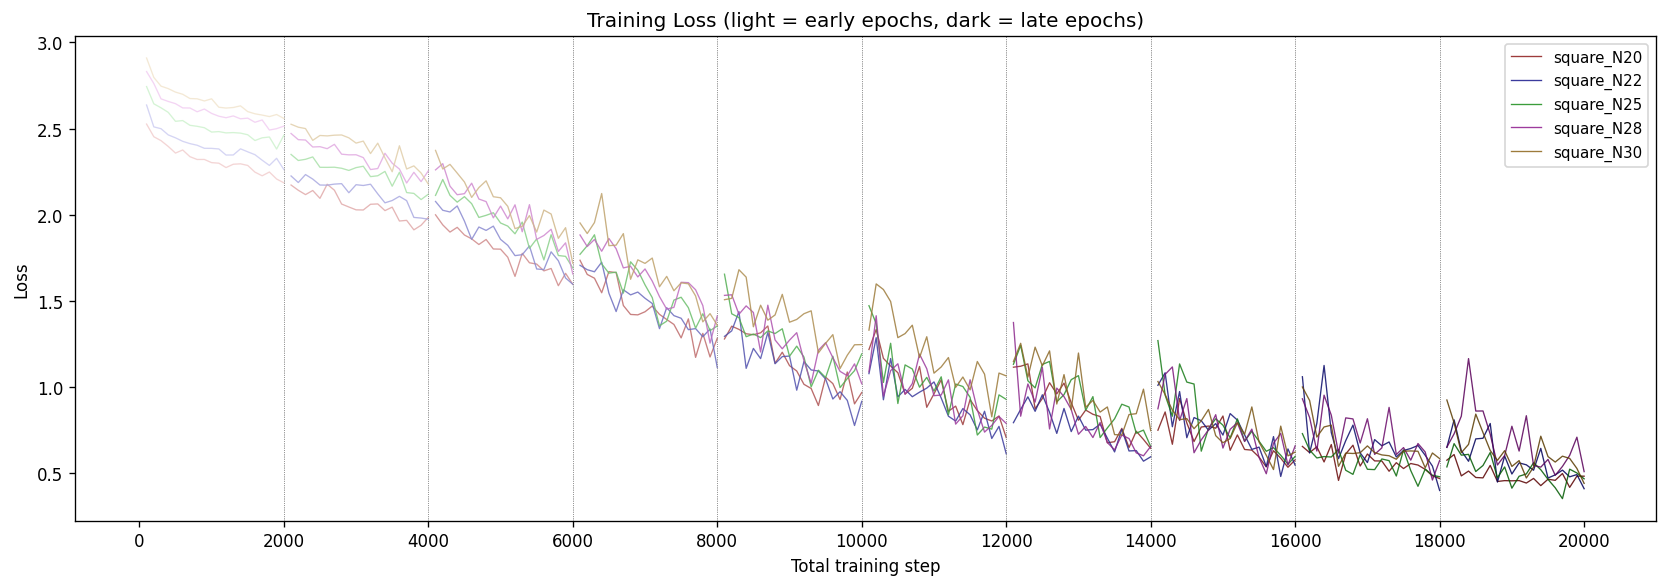

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

max_total_steps = 0
for exp_idx, d in enumerate(data):
    epoch_losses = d["log"]["epoch_losses"]
    if not epoch_losses:
        continue
    steps_per_epoch = d["log"]["max_steps"]
    n_epochs = len(epoch_losses)
    base_color = BASE_HUES[exp_idx % len(BASE_HUES)]
    colors = make_epoch_cmap(base_color, n_epochs)
    label = make_label(d)

    for ep_idx, ep_data in enumerate(epoch_losses):
        if not ep_data:
            continue
        steps, losses = zip(*ep_data)
        global_steps = [s + ep_idx * steps_per_epoch for s in steps]
        ax.plot(global_steps, losses, linewidth=0.8, color=colors[ep_idx], alpha=0.85)

    # Add epoch separators
    for ep_idx in range(1, n_epochs):
        ax.axvline(ep_idx * steps_per_epoch, color="gray", linestyle=":", linewidth=0.5, alpha=0.4)

    max_total_steps = max(max_total_steps, n_epochs * steps_per_epoch)

    # Legend entry: median color, same linewidth as data
    ax.plot([], [], linewidth=0.8, color=colors[n_epochs // 2], label=label)

# Force x-axis ticks aligned with steps_per_epoch
if max_total_steps > 0 and steps_per_epoch > 0:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(steps_per_epoch))

ax.set_xlabel("Total training step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss (light = early epochs, dark = late epochs)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Score Evolution Over Epochs

Key metrics from `metrics.txt`: mean, median, max, and top-1 percentile score at each epoch.

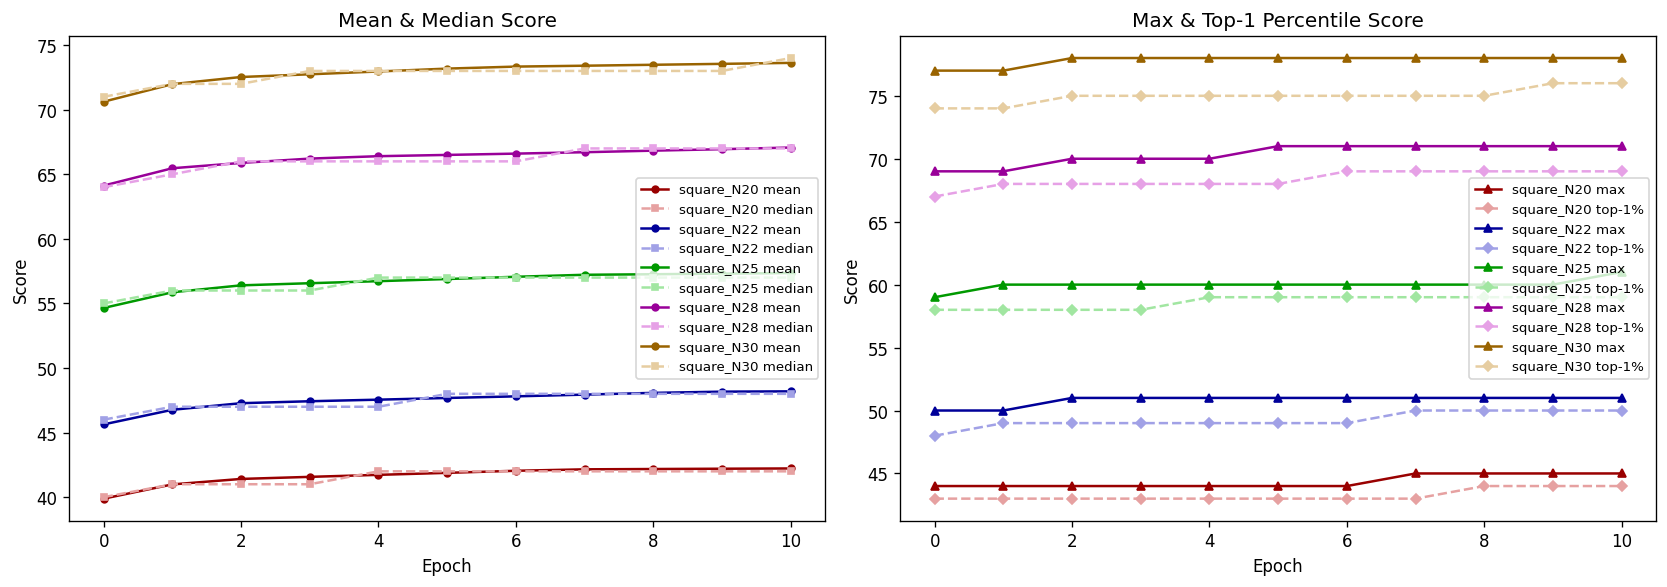

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Mean & Median
ax = axes[0]
for exp_idx, d in enumerate(data):
    if not d["metrics"]:
        continue
    epochs = [m["epoch"] for m in d["metrics"]]
    label = make_label(d)
    base_color = BASE_HUES[exp_idx % len(BASE_HUES)]
    light, dark = make_light_dark(base_color)
    ax.plot(epochs, [m["mean"] for m in d["metrics"]], marker="o", markersize=4, color=dark, linewidth=1.5, label=f"{label} mean")
    ax.plot(
        epochs, [m["median"] for m in d["metrics"]], marker="s", markersize=4, color=light, linewidth=1.5, linestyle="--", label=f"{label} median"
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Mean & Median Score")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Right: Max & Top-1%
ax = axes[1]
for exp_idx, d in enumerate(data):
    if not d["metrics"]:
        continue
    epochs = [m["epoch"] for m in d["metrics"]]
    label = make_label(d)
    base_color = BASE_HUES[exp_idx % len(BASE_HUES)]
    light, dark = make_light_dark(base_color)
    ax.plot(epochs, [m["max"] for m in d["metrics"]], marker="^", markersize=5, color=dark, linewidth=1.5, label=f"{label} max")
    ax.plot(
        epochs, [m["top_1_pct"] for m in d["metrics"]], marker="D", markersize=4, color=light, linewidth=1.5, linestyle="--", label=f"{label} top-1%"
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Max & Top-1 Percentile Score")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Score Distribution

Histogram of scores for the **last recorded distribution** per experiment. Shows how the population concentrates around high-scoring solutions over training.

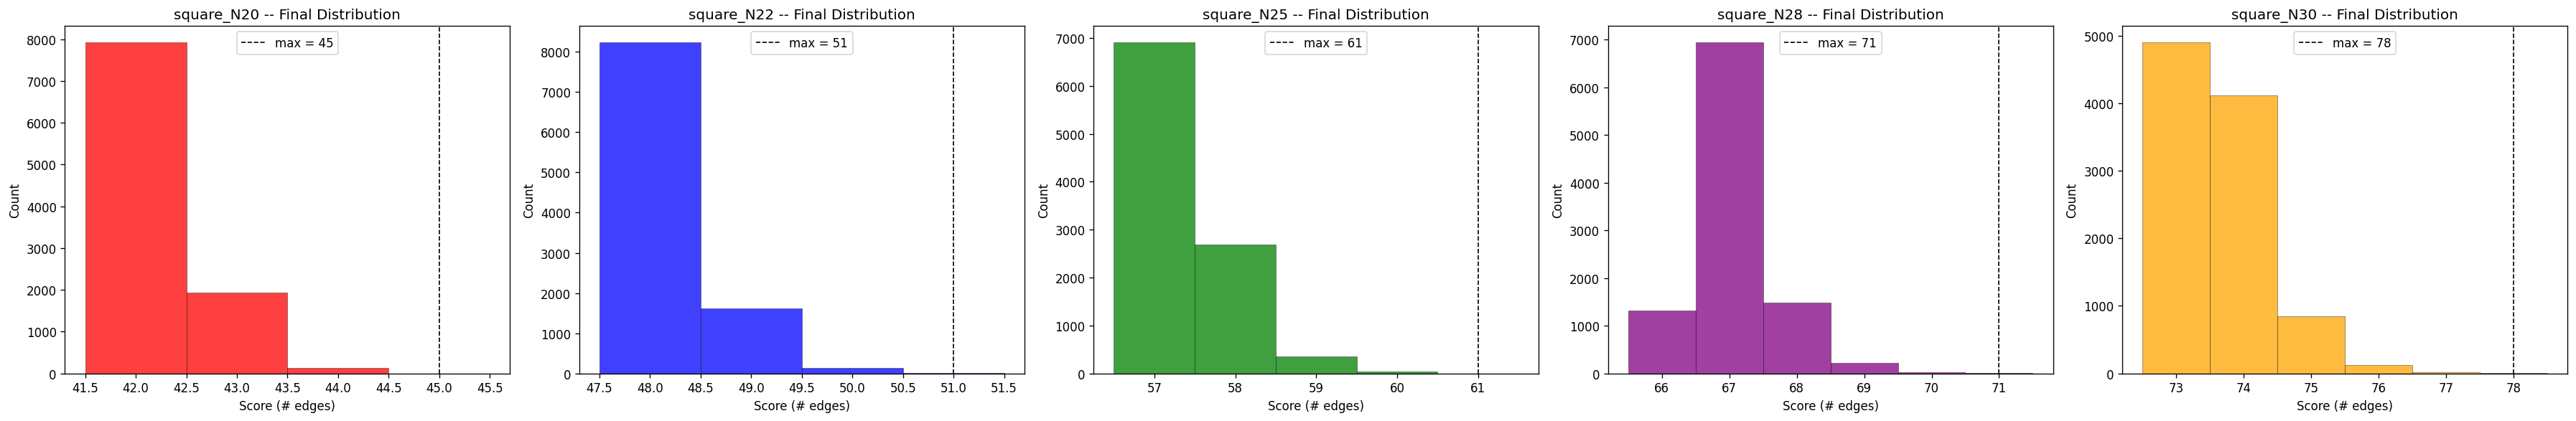

In [15]:
n_exps = len(data)
fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 5), squeeze=False)

for i, d in enumerate(data):
    ax = axes[0, i]
    dists = d["log"]["epoch_distributions"]
    if not dists:
        ax.text(0.5, 0.5, "No distribution data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(make_label(d))
        continue

    base_color = BASE_HUES[i % len(BASE_HUES)]
    last_dist = dists[-1]
    scores = sorted(last_dist.keys())
    counts = [last_dist[s] for s in scores]
    ax.bar(
        scores,
        counts,
        width=max(1, (max(scores) - min(scores)) / len(scores) * 0.9),
        alpha=0.75,
        color=mcolors.to_rgb(base_color),
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_xlabel("Score (# edges)")
    ax.set_ylabel("Count")
    ax.set_title(f"{make_label(d)} -- Final Distribution")

    max_score = max(scores)
    ax.axvline(max_score, color="black", linestyle="--", linewidth=1, label=f"max = {max_score:.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Summary Table

In [9]:
var_cols = sorted(var_args)
col_widths = {}
for v in var_cols:
    values = [str(d["params"].get(v, "")) for d in data]
    col_widths[v] = max(len(v), max((len(val) for val in values), default=0)) + 2

metric_names = ["Epochs", "Mean", "Median", "Top-1%", "Max"]
rows = []
for d in data:
    metrics = d["metrics"]
    if not metrics:
        continue
    last = metrics[-1]
    best_max = max(m["max"] for m in metrics)
    row = {
        "d": d,
        "cells": {
            "Epochs": str(n_training_epochs(metrics)),
            "Mean": f"{last['mean']:.2f}",
            "Median": f"{last['median']:.1f}",
            "Top-1%": f"{last['top_1_pct']:.1f}",
            "Max": f"{last['max']:.0f}",
        },
        "best_max": best_max,
    }
    rows.append(row)

metric_w = {}
for m in metric_names:
    metric_w[m] = max(len(m), max((len(r["cells"][m]) for r in rows), default=0)) + 1

header = f"{'Experiment':<{label_w}}"
for v in var_cols:
    header += f" {v:>{col_widths[v]}}"
for m in metric_names:
    header += f" {m:>{metric_w[m]}}"

print(header)
print("-" * len(header))

for row in sorted(rows, key=lambda r: r["best_max"], reverse=True):
    d = row["d"]
    line = f"{make_label(d):<{label_w}}"
    for v in var_cols:
        line += f" {str(d['params'].get(v, '')):>{col_widths[v]}}"
    for m in metric_names:
        line += f" {row['cells'][m]:>{metric_w[m]}}"
    print(line)

Experiment      N     exp_name  Epochs   Mean  Median  Top-1%  Max
------------------------------------------------------------------
square_N30     30   square_N30      10  73.62    74.0    76.0   78
square_N28     28   square_N28      10  67.07    67.0    69.0   71
square_N25     25   square_N25      10  57.35    57.0    59.0   61
square_N22     22   square_N22      10  48.19    48.0    50.0   51
square_N20     20   square_N20      10  42.22    42.0    44.0   45


## Score Distribution Evolution

How the score distribution shifts across epochs (initial data vs after each training epoch).

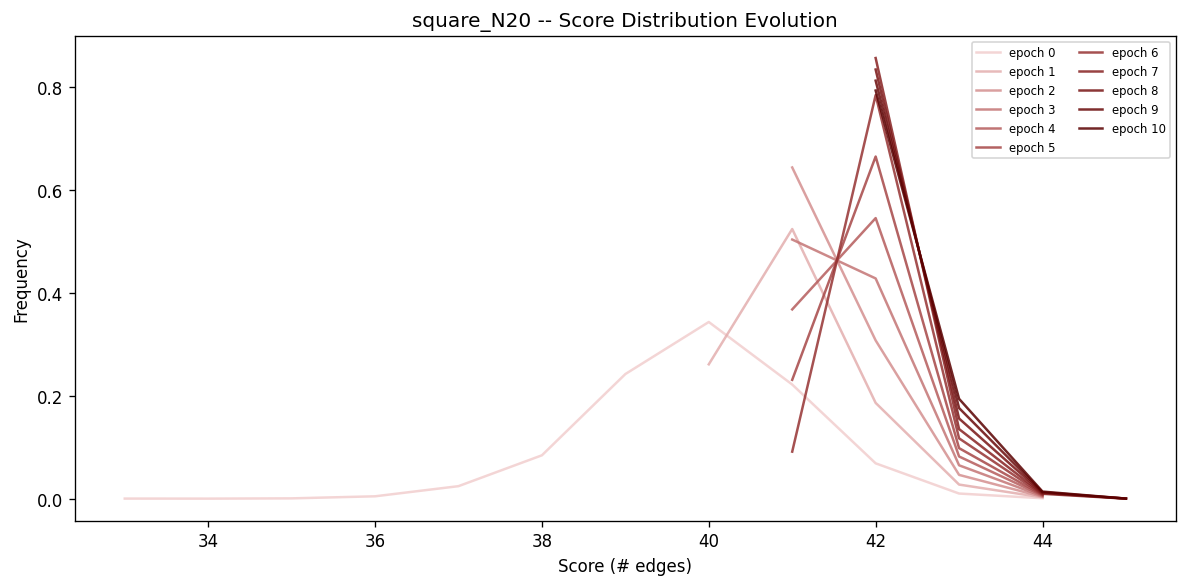

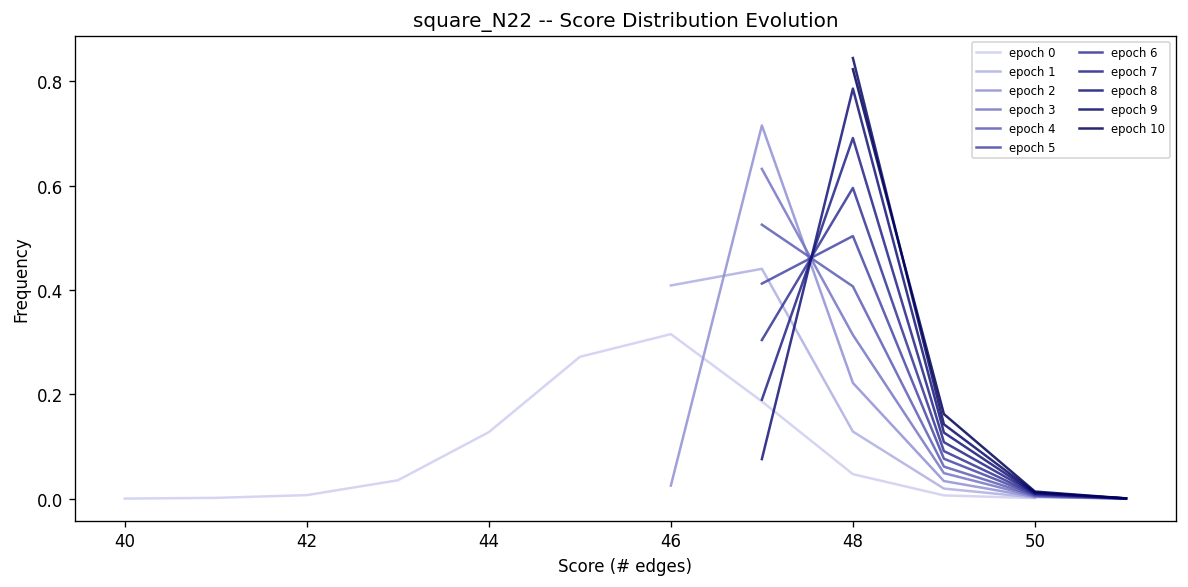

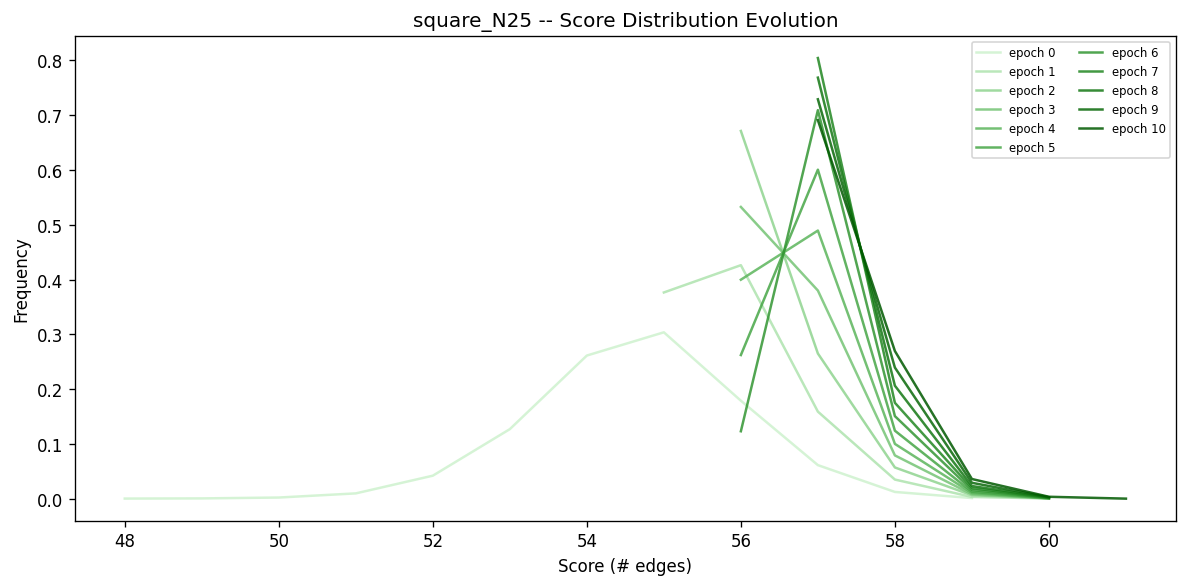

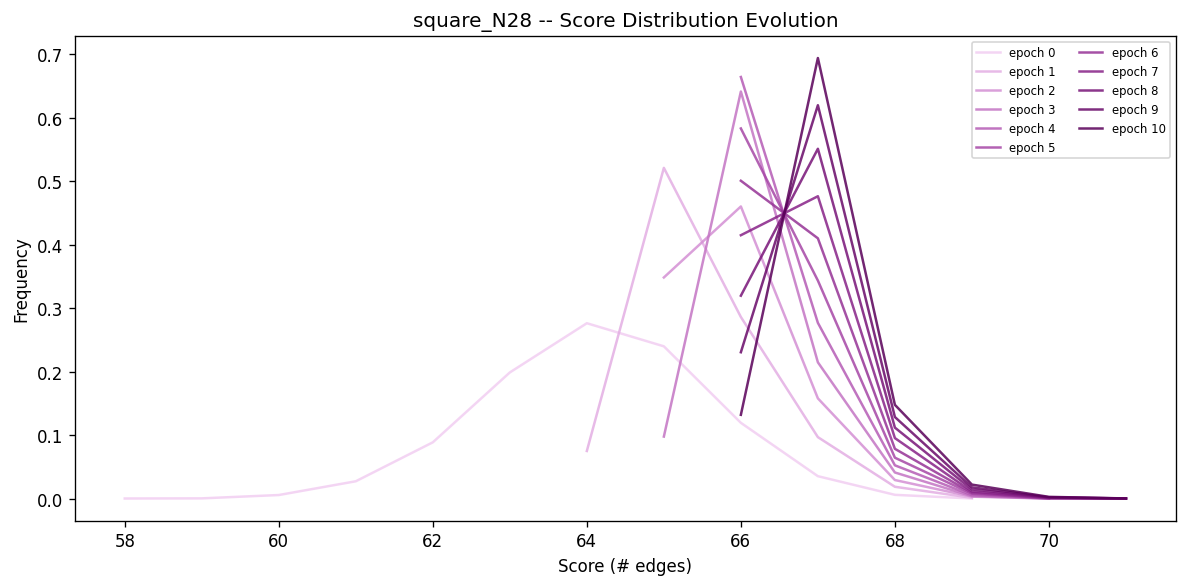

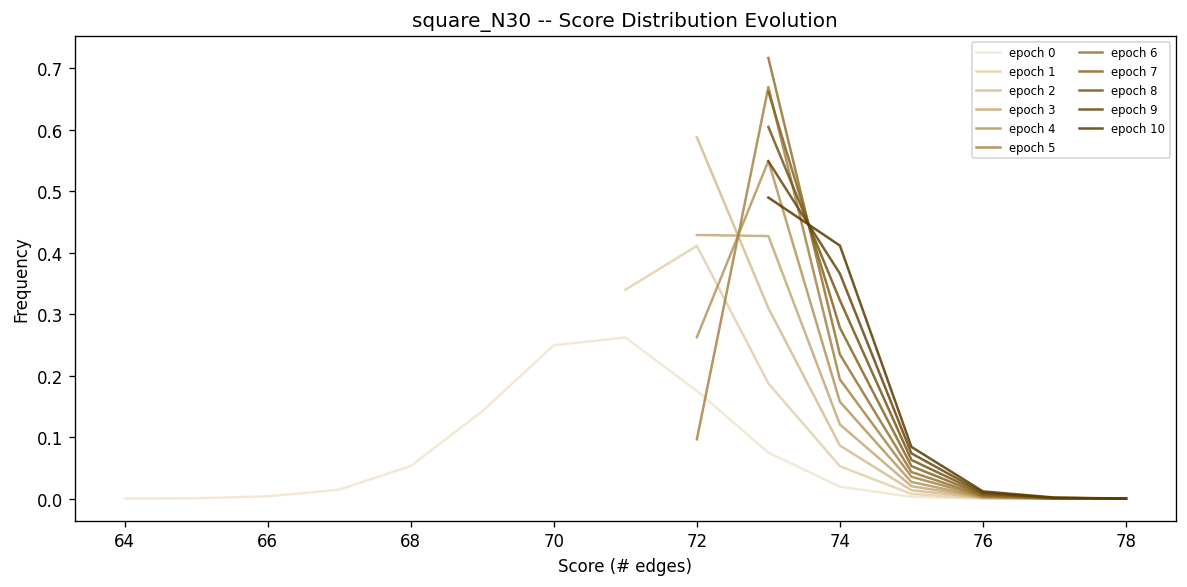

In [16]:
for exp_idx, d in enumerate(data):
    dists = d["log"]["epoch_distributions"]
    metrics = d["metrics"]
    if len(dists) < 2:
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    base_color = BASE_HUES[exp_idx % len(BASE_HUES)]
    n_dists = len(dists)
    colors = make_epoch_cmap(base_color, n_dists)

    for ep_idx, dist in enumerate(dists):
        scores = sorted(dist.keys())
        counts = [dist[s] for s in scores]
        total = sum(counts)
        freqs = [c / total for c in counts]
        epoch_num = metrics[ep_idx]["epoch"] if ep_idx < len(metrics) else ep_idx
        ax.plot(scores, freqs, linewidth=1.5, color=colors[ep_idx], label=f"epoch {epoch_num}", alpha=0.85)

    ax.set_xlabel("Score (# edges)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{make_label(d)} -- Score Distribution Evolution")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()